## 2D Mucus Layer Simulation. Three Distance Scenarios

Does spatial proximity between *Bifido* and *Eubacterium* affect total butyrate output?

**Grid:** 30 × 15 (300 µm wide × 150 µm deep), 10 µm per cell  

In [1]:
import os
# COMETS and Gurobi paths (macOS)
# os.environ['GUROBI_COMETS_HOME'] = '/Library/gurobi1003/macos_universal2'
# os.environ['COMETS_HOME'] = '/Users/fredericksenya/Documents/MATLAB/comets_macos/comets_2.12.3'
# os.environ['CLASSPATH'] = f"{os.environ['COMETS_HOME']}/comets.jar:{os.environ['GUROBI_COMETS_HOME']}/lib/gurobi.jar"
# os.environ['DYLD_LIBRARY_PATH'] = f"{os.environ['GUROBI_COMETS_HOME']}/lib"
# os.environ['GRB_LICENSE_FILE'] = '/Library/gurobi1003/macos_universal2/gurobi.lic'

os.environ['GUROBI_COMETS_HOME'] = '/Library/gurobi1003/macos_universal2'
os.environ['COMETS_HOME'] = '/Users/david/comets_macos/comets_2.12.5'
os.environ['CLASSPATH'] = f"{os.environ['COMETS_HOME']}/comets.jar:{os.environ['GUROBI_COMETS_HOME']}/lib/gurobi.jar"
os.environ['DYLD_LIBRARY_PATH'] = f"{os.environ['GUROBI_COMETS_HOME']}/lib"
os.environ['GRB_LICENSE_FILE'] = '/Users/david/gurobi.lic'

import cobra as cb
import cometspy as c
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
import copy
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
## Load COBRA Models

model_BI = cb.io.load_matlab_model('Bifidobacterium_longum_infantis_ATCC_15697.mat')
model_BI.id = 'b_infantis'

model_AH = cb.io.load_matlab_model('Eubacterium_hallii_DSM_3353.mat')
model_AH.id = 'a_hallii'

print(f"B. infantis: {len(model_BI.reactions)} rxns, {len(model_BI.metabolites)} mets, {len(model_BI.exchanges)} exchanges")
print(f"A. hallii: {len(model_AH.reactions)} rxns, {len(model_AH.metabolites)} mets, {len(model_AH.exchanges)} exchanges")

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-19


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


B. infantis: 1032 rxns, 932 mets, 163 exchanges
A. hallii: 1051 rxns, 980 mets, 120 exchanges


## Set up COMETS Simulations

Valid Parameters and Options (See pdf below, page 26)

[Supplement Discussions (PDF)](https://pmc.ncbi.nlm.nih.gov/articles/instance/10824140/bin/NIHMS1948756-supplement-Supplement_Discussions.pdf)

---

GEMs Files available [AGORA2 at vmh.life](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/) or directly:

[*Anaerobutyricum hallii* - *A. hallii* (Previously Eubacterium hallii)](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Eubacterium_hallii_DSM_3353.mat) 

[*Bifidobacterium longum sbsp. infantis* - *B. infantis*](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Bifidobacterium_longum_infantis_ATCC_15697.mat) 

In [3]:
# Build Exchange Metabolite Union & Add Missing Exchanges

met_to_ex_BI, met_to_ex_AH = {}, {}
for rxn in model_BI.exchanges:
    if rxn.metabolites:
        met_to_ex_BI[list(rxn.metabolites.keys())[0].id] = rxn.id
for rxn in model_AH.exchanges:
    if rxn.metabolites:
        met_to_ex_AH[list(rxn.metabolites.keys())[0].id] = rxn.id

all_ext_mets = set(met_to_ex_BI.keys()) | set(met_to_ex_AH.keys())
print(f"Total unique external metabolites: {len(all_ext_mets)}")

def add_missing_closed_exchanges(model, met_to_ex_self, all_ext_mets, label):
    met_ids = {m.id for m in model.metabolites}
    rxn_ids = {r.id for r in model.reactions}
    added = 0
    for met_id in all_ext_mets:
        if met_id in met_to_ex_self:
            continue
        if met_id in met_ids:
            met = model.metabolites.get_by_id(met_id)
        else:
            met = cb.Metabolite(met_id, compartment='e')
            model.add_metabolites([met])
            met_ids.add(met_id)
        rxn_id = f'EX_added_{met_id}'
        if rxn_id in rxn_ids:
            continue
        rxn = cb.Reaction(rxn_id)
        rxn.name = f'Dummy exchange for {met_id} (closed)'
        rxn.lower_bound = 0.0
        rxn.upper_bound = 0.0
        rxn.add_metabolites({met: -1.0})
        model.add_reactions([rxn])
        rxn_ids.add(rxn_id)
        added += 1
    #print(f'[{label}] Added {added} closed dummy exchanges')

add_missing_closed_exchanges(model_BI, met_to_ex_BI, all_ext_mets, 'b_infantis')
add_missing_closed_exchanges(model_AH, met_to_ex_AH, all_ext_mets, 'a_hallii')

Total unique external metabolites: 188


In [4]:
# Set exchange bounds for COMETS
for m in [model_BI, model_AH]:
    for rxn in m.exchanges:
        rxn.lower_bound = 0.0
        rxn.upper_bound = 1000.0


In [5]:
# GRID 

GRID_X = 30
GRID_Y = 15
MUCUS_THICKNESS_UM = 150

SPACE_WIDTH = MUCUS_THICKNESS_UM / GRID_Y / 1e4   # cm per cell = 0.001 cm = 10 µm
BOX_VOL_CM3 = SPACE_WIDTH ** 3
BOX_VOL_ML  = BOX_VOL_CM3
BOX_VOL_L   = BOX_VOL_ML * 1e-3

def mM_to_mmol(conc_mM):
    return conc_mM * BOX_VOL_L

def mmol_to_mM(amount_mmol):
    return amount_mmol / BOX_VOL_L

# Aqueous diffusion coefficients (cm²/s)
D_glucose_aq   = 6.7e-6
D_lactate_aq   = 1.1e-5
D_acetate_aq   = 1.2e-5
D_butyrate_aq  = 0.9e-5
D_generic_aq   = 8.0e-6

MUCUS_FACTOR_GLUCOSE  = 0.003
MUCUS_FACTOR_SECRETED = 0.003
MUCUS_FACTOR_DEFAULT  = 0.003

D_GLUCOSE  = D_glucose_aq  * MUCUS_FACTOR_GLUCOSE
D_LACTATE  = D_lactate_aq  * MUCUS_FACTOR_SECRETED
D_ACETATE  = D_acetate_aq  * MUCUS_FACTOR_SECRETED
D_BUTYRATE = D_butyrate_aq * MUCUS_FACTOR_SECRETED
D_DEFAULT  = D_generic_aq  * MUCUS_FACTOR_DEFAULT

TIME_STEP = 0.01
NUM_DIFF_PER_STEP = 10

In [6]:
# metabolites

GLC_CONC_mM = 10.0
GLC_TOP = mM_to_mmol(GLC_CONC_mM)

WATER_AMOUNT = 1e-4
MAJOR_ION = mM_to_mmol(5.0)
AA_AMOUNT = mM_to_mmol(2.0)
TRACE_AMOUNT = mM_to_mmol(0.1)
VIT_AMOUNT = mM_to_mmol(0.1)

# Metabolite categories
water_proton_ids = {'h2o[e]'}
major_ion_ids = {'pi[e]', 'so4[e]', 'nh4[e]','k[e]', 'cl[e]', 'mg2[e]', 'ca2[e]',}
trace_metal_ids = {'fe2[e]', 'fe3[e]', 'zn2[e]', 'cu2[e]', 'mn2[e]', 'cobalt2[e]', 'cd2[e]',}
vitamin_ids = {'ribflv[e]', 'pnto_R[e]', 'nac[e]', 'hxan[e]',}
aa_ids = {'ala_L[e]', 'asn_L[e]', 'his_L[e]', 'leu_L[e]', 'lys_L[e]', 'met_L[e]', 'glycys[e]', 'glyglu[e]',}
glucose_id = 'glc_D[e]'

met_categories = {}
for met_id in all_ext_mets:
    if met_id == glucose_id:
        met_categories[met_id] = ('glucose', GLC_TOP)
    elif met_id in water_proton_ids:
        met_categories[met_id] = ('water_proton', WATER_AMOUNT)
    elif met_id in major_ion_ids:
        met_categories[met_id] = ('major_ion', MAJOR_ION)
    elif met_id in trace_metal_ids:
        met_categories[met_id] = ('trace_metal', TRACE_AMOUNT)
    elif met_id in vitamin_ids:
        met_categories[met_id] = ('vitamin', VIT_AMOUNT)
    elif met_id in aa_ids:
        met_categories[met_id] = ('amino_acid', AA_AMOUNT)

In [7]:
# Biomass motion parameter

D0_biomass = 1e-10
Dn_biomass = 1e-8
n_exp      = 1.0
N_hill     = 2.0
K_half     = 1e-12

# Distance Scenarios

In [8]:
# Scenarios

INIT_BIOMASS = 5e-10   # grams 
y_init = 2             
MAX_CYCLES = 600

scenarios = {
    's020': {'x_BI': 14, 'x_AH': 16},
    's060': {'x_BI': 12, 'x_AH': 18},
    's100': {'x_BI': 10, 'x_AH': 20},
    's140': {'x_BI': 8, 'x_AH': 22},
    's180': {'x_BI': 6, 'x_AH': 24},
    's220': {'x_BI': 4, 'x_AH': 26},
    's260': {'x_BI': 2, 'x_AH': 28},
}


for name, pos in scenarios.items():
    sep = abs(pos['x_AH'] - pos['x_BI']) * SPACE_WIDTH * 1e4

In [9]:
def run_scenario(model_BI, model_AH, x_BI, x_AH, scenario_name):

    print(f"Running: {scenario_name}")
    print(f"  B. infantis at x={x_BI}, y={y_init}")
    print(f"  A. hallii   at x={x_AH}, y={y_init}")

    comets_BI = c.model(model_BI)
    comets_AH = c.model(model_AH)

    comets_BI.open_exchanges()
    comets_AH.open_exchanges()

    # Clean non-EX exchanges (COMETS fix)
    for m in [comets_BI, comets_AH]:
        ex_mask = m.reactions['EXCH'].isin([True, 'True'])
        exchanges_df = m.reactions[ex_mask]
        for name in exchanges_df['REACTION_NAMES']:
            name = str(name)
            if not name.startswith('EX_'):
                m.reactions.loc[m.reactions['REACTION_NAMES'] == name, 'EXCH'] = False
                m.reactions.loc[m.reactions['REACTION_NAMES'] == name, 'EXCH_IND'] = 0

    comets_BI.initial_pop = [[x_BI, y_init, INIT_BIOMASS]]
    comets_AH.initial_pop = [[x_AH, y_init, INIT_BIOMASS]]

    # Biomass motion
    for m in [comets_BI, comets_AH]:
        m.add_nonlinear_diffusion_parameters(D0_biomass, Dn_biomass, n_exp, N_hill, K_half)

    # Layout
    layout = c.layout([comets_BI, comets_AH])
    layout.grid = [GRID_X, GRID_Y]


    for met in all_ext_mets:
        layout.set_specific_metabolite(met, 0.0)
        layout.set_specific_refresh(met, 0.0)

    # Set nutrients (static except glucose)
    for met_id, (category, amount) in met_categories.items():
        if category == 'glucose':
            continue
        if amount > 0:
            layout.set_specific_metabolite(met_id, amount)
            layout.set_specific_static(met_id, amount)

    # Glucose: top row static supply
    for x in range(GRID_X):
        layout.set_specific_metabolite_at_location(glucose_id, (x, 0), GLC_TOP)
        layout.set_specific_static_at_location(glucose_id, (x, 0), GLC_TOP)

    for x in range(GRID_X):
        layout.set_specific_metabolite_at_location(glucose_id, (x, GRID_Y - 1), 0.0)
        layout.set_specific_static_at_location(glucose_id, (x, GRID_Y - 1), 0.0)

    # Metabolite specific diffusion
    layout.set_specific_metabolite_diffusion(glucose_id, D_GLUCOSE)
    secreted_diffusion = {'lac_L[e]': D_LACTATE, 'ac[e]': D_ACETATE, 'but[e]': D_BUTYRATE}
    for met, d_val in secreted_diffusion.items():
        if met in all_ext_mets:
            layout.set_specific_metabolite_diffusion(met, d_val)

    # Parameters
    params = c.params()
    params.set_param('maxCycles', MAX_CYCLES)
    params.set_param('timeStep', TIME_STEP)
    params.set_param('spaceWidth', SPACE_WIDTH)
    params.set_param('exchangestyle', 'Monod Style')
    params.set_param('defaultVmax', 20.0)
    params.set_param('defaultKm', 5e-4)
    params.set_param('defaultHill', 1)
    params.set_param('defaultDiffConst', D_DEFAULT)
    params.set_param('numDiffPerStep', NUM_DIFF_PER_STEP)
    params.set_param('biomassMotionStyle', 'ConvNonlin Diffusion 2D')
    params.set_param('growthDiffRate', 0.0)
    params.set_param('maxSpaceBiomass', 1e-9)
    params.set_param('minSpaceBiomass', 1e-14)
    params.set_param('allowCellOverlap', True)
    params.set_param('deathRate', 0.0)

    LOG_RATE = 5
    params.set_param('writeBiomassLog', True)
    params.set_param('BiomassLogRate', LOG_RATE)
    params.set_param('writeMediaLog', True)
    params.set_param('MediaLogRate', LOG_RATE)
    params.set_param('writeFluxLog', True)
    params.set_param('FluxLogRate', LOG_RATE)
    params.set_param('writeTotalBiomassLog', True)
    params.set_param('totalBiomassLogRate', LOG_RATE)

    # Run
    sim = c.comets(layout, params)
    sim.run()

    return sim


In [10]:
# run simulation

results = {}
for scenario_name, pos in scenarios.items():
    sim = run_scenario(model_BI, model_AH, pos['x_BI'], pos['x_AH'], scenario_name)
    results[scenario_name] = sim
    

Running: s020
  B. infantis at x=14, y=2
  A. hallii   at x=16, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s060
  B. infantis at x=12, y=2
  A. hallii   at x=18, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s100
  B. infantis at x=10, y=2
  A. hallii   at x=20, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s140
  B. infantis at x=8, y=2
  A. hallii   at x=22, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s180
  B. infantis at x=6, y=2
  A. hallii   at x=24, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s220
  B. infantis at x=4, y=2
  A. hallii   at x=26, y=2

Running COMETS simulation ...

Debug Here ...
Done!
Running: s260
  B. infantis at x=2, y=2
  A. hallii   at x=28, y=2

Running COMETS simulation ...

Debug Here ...
Done!


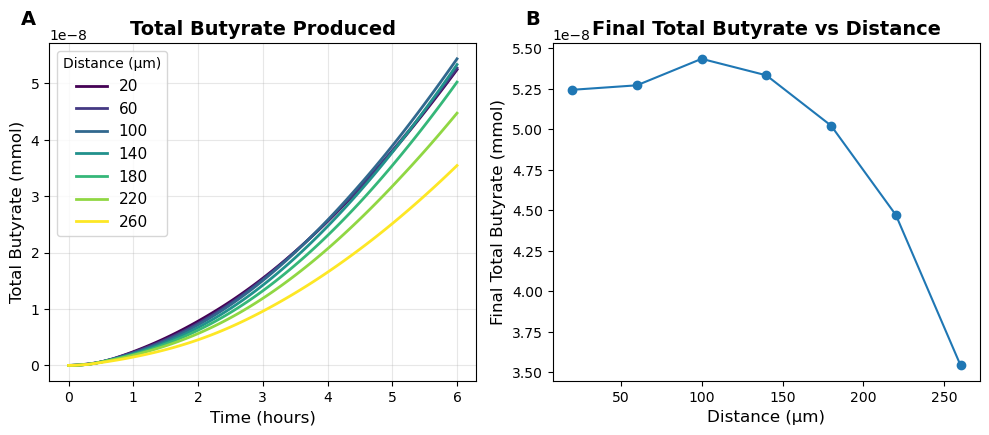

In [ ]:
# Total Butyrate
fig, ax = plt.subplots(1,2,figsize=(10, 4.5))
                                    
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(results)))
distances = [int(str(key).replace('s', '')) for key in results.keys()]

for i, (name, sim) in enumerate(results.items()):
    bio = sim.total_biomass
    logged_cycles = bio['cycle'].values
    time_h = logged_cycles * TIME_STEP
    # extract sum of met conc across grid per cycle
    total_butyrate = sim.get_metabolite_time_series(upper_threshold=1e12)['but[e]'].values 
    ax[0].plot(time_h, total_butyrate,color=colors[i], lw=2, label=distances[i])
ax[0].set_xlabel('Time (hours)', fontsize=12)
ax[0].set_ylabel('Total Butyrate (mmol)', fontsize=12)
ax[0].set_title('Total Butyrate Produced', fontsize=14, fontweight='bold')
ax[0].legend(title='Distance (µm)',fontsize=11)
ax[0].grid(True, alpha=0.3)

final_butyrate = [sim.get_metabolite_time_series(upper_threshold=1e12)['but[e]'].values[-1] for sim in results.values()]
ax[1].plot(distances, final_butyrate, marker='o')
ax[1].set_xlabel('Distance (µm)', fontsize=12)
ax[1].set_ylabel('Final Total Butyrate (mmol)', fontsize=12)
ax[1].set_title('Final Total Butyrate vs Distance', fontsize=14, fontweight='bold')

labels = ['A', 'B']
for a, label in zip(ax.flat, labels):
    # label in top-left, outside plot
    a.text(
        -0.03, 1.10, label,
        transform=a.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='right')

plt.tight_layout()
#plt.savefig('spatial_distance.png', dpi=600, bbox_inches='tight')
plt.show()